In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# import tensorflow as tf
# from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input, Maxpooling
# from tensorflow.keras.models import Model

In [ ]:
# #one step encoder block
# def encoder_block(filters, inputs):
#   x=Conv2D(filters, kernel_size=(3,3), padding='same', strides=1, activation='ReLu')(inputs)
#   s=Conv2D(filters, kernel_size=(3,3), padding='same', strides=1, activation='ReLu')(x)
#   p=MaxPooling2D(pool_size=(2,2), padding='same')(s)
#   return s,p

In [ ]:
# #baseline -> convolutional layers to extract the high level features from a downsampled image
# def baseline_layer(filters, inputs):
#   x=Conv2D(filters, kernel_size=(3,3), padding='same', strides=1, activation='ReLu')(inputs)
#   x=Conv2D(filters, kernel_size=(3,3), padding='same', strides=1, activation='ReLu')(x)
#   return x

In [ ]:
# #decoder layer function
# def decoder_block(filters, connections, inputs):
#   x=Conv2DTranspose(filters, kernel_size=(2,2), strides=2, padding='same', activation='ReLu')(inputs)
#   skip_connections = concatenate([x,connections], axis=-1)
#   x=Conv2D(filters, kernel_size=(3,3), padding='same', activation='ReLu')(skip_connections)
#   x=Conv2D(filters, kernel_size=(3,3), padding='same', activation='ReLu')(x)
#   return x

In [ ]:
# def U-Net:
#   inputs=Input(shape=(224, 224, 1))

#   #defining the encoder
#   s1, p1=encoder_block(64, inputs=inputs)
#   s2, p2=encoder_block(128, inputs=p1)
#   s3, p3=encoder_block(256, inputs=p2)
#   s4, p4=encoder_block(512, inputs=p3)

#   #setting up the baseline
#   baseline = baseline_layer(1024, inputs=p4)

#   #defining the decoder
#   d1 = decoder_block(512, s4, inputs=baseline)
#   d2 = decoder_block(256, s3, inputs=d1)
#   d3 = decoder_block(128, s2, inputs=d2)
#   d4 = decoder_block(64, s1, inputs=d3)

#   #setting up the output fucntion for binary output
#   outputs = Conv2D(1, 1, activation='sigmoid')(d4)

#   #finalizing the model
#   model = Model(inputs=inputs, outputs=outputs, name='U-Net')
#   return model

# Preprocessing - transformations and visualizations

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# --- 1. SETUP KAGGLE ENVIRONMENT ---
!pip uninstall -y monai torch torchvision torchaudio
!pip install "monai[nibabel,tqdm]>=1.3.0" "einops" --upgrade -q
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install torchio
print("Environment setup complete. Please RESTART THE SESSION now from the 'Run' menu.")

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.7/766.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install SimpleITK

In [ ]:
!pip install joblib

## Testing the masking approach

In [ ]:
# !rm -rf "/content/drive/MyDrive/InputScans"

In [ ]:
# import os
# import glob
# import torch
# import numpy as np
# import SimpleITK as sitk
# from tqdm import tqdm
# import cv2
# from joblib import Parallel, delayed
# import traceback

# # =====================================================================================
# # Configuration
# # =====================================================================================
# data_root = "/content/drive/MyDrive/BraTS Challenge 2025 - Task 6/BraTS2024-PED-Challenge-TrainingData/BraTS-PEDs2024_Training"
# modalities = ["t1c", "t1n", "t2f", "t2w"]
# save_dir = "/content/drive/MyDrive/InputScans"
# os.makedirs(save_dir, exist_ok=True)

# # =====================================================================================
# # Helper Functions
# # =====================================================================================

# def n4_bias_correction(img_np):
#     """
#     Performs N4 Bias Field Correction on a 3D numpy array with shape [D, H, W].
#     """
#     sitk_img = sitk.GetImageFromArray(img_np)
#     sitk_img = sitk.Cast(sitk_img, sitk.sitkFloat32)
#     mask = sitk.OtsuThreshold(sitk.Cast(sitk_img, sitk.sitkUInt8), 0, 1)
#     corrector = sitk.N4BiasFieldCorrectionImageFilter()
#     corrected_full = sitk.N4BiasFieldCorrection(sitk_img, mask)
#     return sitk.GetArrayFromImage(corrected_full)

# def apply_anisotropic_diffusion(image_tensor):
#     """Applies anisotropic diffusion to a single 3D image tensor."""
#     sitk_image = sitk.GetImageFromArray(image_tensor.numpy())
#     diff_filter = sitk.CurvatureAnisotropicDiffusionImageFilter()
#     diff_filter.SetTimeStep(0.0625)
#     diff_filter.SetNumberOfIterations(5)
#     diff_filter.SetConductanceParameter(9.0)
#     filtered_image = diff_filter.Execute(sitk_image)
#     return torch.from_numpy(sitk.GetArrayFromImage(filtered_image))

# def get_gradient_magnitude(image_tensor):
#     """Calculates the 3D gradient magnitude."""
#     sitk_image = sitk.GetImageFromArray(image_tensor.float().numpy())
#     grad_filter = sitk.GradientMagnitudeRecursiveGaussianImageFilter()
#     grad_filter.SetSigma(1.0)
#     grad_image = grad_filter.Execute(sitk_image)
#     return torch.from_numpy(sitk.GetArrayFromImage(grad_image))

# def enhance_contrast_gpu(image_tensor):
#     """Enhances contrast using CLAHE."""
#     img_np = image_tensor.detach().cpu().numpy()
#     C, D, H, W = img_np.shape
#     enhanced = np.zeros_like(img_np)
#     for c in range(C):
#         for d in range(D):
#             slice_ = img_np[c, d, :, :].astype(np.float32)
#             normalized = cv2.normalize(slice_, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
#             clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
#             enhanced[c, d] = clahe.apply(normalized)
#     return torch.tensor(enhanced).float()

# def crop_to_brain(image, label, margin=5):
#     """Crops the image and label to the brain region."""
#     nonzero_mask = image != 0
#     combined_mask = nonzero_mask.any(0)
#     coords = torch.nonzero(combined_mask)
#     if coords.numel() == 0: return None, None
#     dmin, hmin, wmin = torch.clamp(coords.min(0)[0] - margin, min=0).tolist()
#     dmax, hmax, wmax = torch.clamp(coords.max(0)[0] + margin, max=torch.tensor(image.shape[1:])).tolist()
#     cropped_image = image[:, dmin:dmax, hmin:hmax, wmin:wmax]
#     cropped_label = label[dmin:dmax, hmin:hmax, wmin:wmax]
#     return cropped_image, cropped_label

# # =====================================================================================
# # Main Patient Processing Function
# # =====================================================================================

# def process_patient(patient_path):
#     patient_id = os.path.basename(patient_path)
#     output_file = os.path.join(save_dir, f"{patient_id}.pt")
#     temp_output_file = output_file + ".tmp"

#     if os.path.exists(output_file): return "skipped", patient_id
#     if os.path.exists(temp_output_file): os.remove(temp_output_file)

#     modality_paths = [os.path.join(patient_path, f"{patient_id}-{m}.nii.gz") for m in modalities]
#     label_path = os.path.join(patient_path, f"{patient_id}-seg.nii.gz")

#     if not all(os.path.exists(p) for p in modality_paths + [label_path]):
#         return "skipped_missing_file", patient_id

#     try:
#         from monai.transforms import LoadImage
#         # LoadImage(image_only=False) is necessary to get metadata like affine
#         image_loader = LoadImage(image_only=False)

#         # 1. Load Data and Standardize Dimensions
#         modalities_list = []
#         affine = None
#         for path in modality_paths:
#             meta_tensor, meta_data = image_loader(path)
#             # MONAI loads as [H, W, D], so we permute to [D, H, W]
#             modalities_list.append(torch.from_numpy(meta_tensor.numpy()).float().permute(2, 0, 1))
#             if affine is None:
#                 affine = meta_data.get("affine") # Get affine from the first modality
#         modalities_tensor = torch.stack(modalities_list)

#         label_meta_tensor, _ = image_loader(label_path)
#         label_tensor = torch.from_numpy(label_meta_tensor.numpy()).long().permute(2, 0, 1)

#         # 2. N4 Bias Correction
#         image_n4 = torch.stack([torch.tensor(n4_bias_correction(modalities_tensor[i].numpy())) for i in range(4)])

#         # 3. Anisotropic Diffusion
#         image_aniso = torch.stack([apply_anisotropic_diffusion(image_n4[i]) for i in range(4)])

#         # 4. Contrast Enhancement (CLAHE)
#         image_clahe = enhance_contrast_gpu(image_aniso)

#         # 5. Gradient Magnitude Feature
#         grad_map = get_gradient_magnitude(image_clahe[0]).unsqueeze(0)

#         # 6. Combine channels
#         image_to_crop = torch.cat([image_clahe, grad_map], dim=0)

#         # 7. Skull Cropping
#         cropped_image, cropped_label = crop_to_brain(image_to_crop, label_tensor)
#         if cropped_image is None: return "error_empty_image", patient_id

#         # 8. Atomic Save
#         torch.save({"image": cropped_image.half(), "label": cropped_label}, temp_output_file)
#         os.rename(temp_output_file, output_file)

#         return "processed", patient_id

#     except Exception as e:
#         if os.path.exists(temp_output_file): os.remove(temp_output_file)
#         return "error", patient_id, str(e)

# # =====================================================================================
# # Parallel Wrapper and Execution Block
# # =====================================================================================

# def safe_process(patient_path):
#     """Wrapper to catch unexpected crashes in the parallel execution."""
#     try:
#         return process_patient(patient_path)
#     except Exception as e:
#         return "crash", os.path.basename(patient_path), str(e)

# if __name__ == "__main__":
#     all_patients = sorted(glob.glob(os.path.join(data_root, "BraTS-PED-*")))
#     print(f"Found {len(all_patients)} patients to process.")

#     results = Parallel(n_jobs=-1)(
#         delayed(safe_process)(p) for p in tqdm(all_patients, desc="Preprocessing Patients")
#     )

#     # Log results
#     processed = {r[1] for r in results if r[0] == "processed"}
#     skipped = {r[1] for r in results if "skipped" in r[0]}
#     errored = {r[1]: r[2] for r in results if r[0] == "error"}
#     crashed = {r[1]: r[2] for r in results if r[0] == "crash"}

#     with open(os.path.join(save_dir, "processed_patients.txt"), "w") as f:
#         for p in sorted(processed): f.write(f"{p}\n")
#     with open(os.path.join(save_dir, "skipped_patients.txt"), "w") as f:
#         for p in sorted(skipped): f.write(f"{p}\n")
#     with open(os.path.join(save_dir, "errored_patients.txt"), "w") as f:
#         for p, err in errored.items(): f.write(f"{p}: {err}\n")
#     with open(os.path.join(save_dir, "crashed_patients.txt"), "w") as f:
#         for p, err in crashed.items(): f.write(f"{p}: {err}\n")

#     print(f"\n--- Preprocessing Complete ---")
#     print(f"Successfully processed: {len(processed)}")
#     print(f"Skipped: {len(skipped)}")
#     print(f"Errored: {len(errored)}")
#     print(f"Crashed: {len(crashed)}")

## end of testing

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm

In [ ]:
import multiprocessing as mp
mp.set_start_method("spawn", force=True)

In [ ]:
processed_patients = set()
skipped_patients = set()
errored_patients = {}


testing with atomic saving and unoform voxel spacing

In [ ]:
import os
import glob
import torch
import numpy as np
import SimpleITK as sitk
from tqdm import tqdm
import cv2
from joblib import Parallel, delayed
import traceback
# --- NEW: Import torchio for advanced medical image processing ---
import torchio as tio
from torchio.data import Subject, ScalarImage
from torchio.transforms import NyulStandardization


# =====================================================================================
# Configuration
# =====================================================================================
data_root = "/content/drive/MyDrive/BraTS Challenge 2025 - Task 6/BraTS2024-PED-Challenge-TrainingData/BraTS-PEDs2024_Training"
modalities = ["t1c", "t1n", "t2f", "t2w"]
save_dir = "/content/drive/MyDrive/InputScans_Final"
os.makedirs(save_dir, exist_ok=True)

# --- NEW: Configuration for Resampling and Standardization ---
# TARGET_SPACING will be determined dynamically
TARGET_ORIENTATION = "RAI" # A standard anatomical orientation
NYUL_LANDMARKS_PATH = os.path.join(save_dir, "nyul_landmarks.npy")
NYUL_TRAINING_PATIENT_COUNT = 20 # Use first 20 patients to train the normalizer

# =====================================================================================
# Helper Functions (Updated and New)
# =====================================================================================

def get_median_spacing(patient_paths):
    """
    Analyzes the dataset to find the median voxel spacing.
    This is the best practice for determining the target resampling spacing.
    """
    spacings = []
    for patient_path in tqdm(patient_paths, desc="Analyzing Voxel Spacings"):
        patient_id = os.path.basename(patient_path)
        # We only need to check one modality per patient as they share the same space
        t1c_path = os.path.join(patient_path, f"{patient_id}-t1c.nii.gz")
        if os.path.exists(t1c_path):
            try:
                img_itk = sitk.ReadImage(t1c_path)
                spacings.append(img_itk.GetSpacing())
            except Exception as e:
                print(f"Could not read spacing for {patient_id}: {e}")

    if not spacings:
        raise RuntimeError("Could not read any spacings from the dataset. Check paths.")

    spacings_np = np.array(spacings)
    median_spacing = np.median(spacings_np, axis=0)
    return tuple(median_spacing)

def resample_and_reorient_sitk(sitk_image, target_spacing, target_orientation, is_label=False):
    """Resamples an image to a target spacing and reorients it."""
    original_spacing = sitk_image.GetSpacing()
    original_size = sitk_image.GetSize()

    # Calculate new size based on target spacing
    new_size = [
        int(round(osz * ospc / tspc))
        for osz, ospc, tspc in zip(original_size, original_spacing, target_spacing)
    ]

    # Set up the resampler
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(target_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(sitk_image.GetDirection())
    resampler.SetOutputOrigin(sitk_image.GetOrigin())
    resampler.SetTransform(sitk.Transform())
    resampler.SetDefaultPixelValue(sitk_image.GetPixelIDValue())

    if is_label:
        resampler.SetInterpolator(sitk.sitkNearestNeighbor)
    else:
        resampler.SetInterpolator(sitk.sitkBSpline)

    resampled_image = resampler.Execute(sitk_image)

    # Reorient the image
    orient_filter = sitk.DICOMOrientImageFilter()
    orient_filter.SetDesiredCoordinateOrientation(target_orientation)
    oriented_image = orient_filter.Execute(resampled_image)
    return oriented_image


def n4_bias_correction_fast(img_np):
    sitk_image = sitk.GetImageFromArray(img_np)
    sitk_image = sitk.Cast(sitk_image, sitk.sitkFloat32)
    mask_image = sitk.OtsuThreshold(sitk_image, 0, 1, 1)
    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrected_image = corrector.Execute(sitk_image, mask_image)
    return sitk.GetArrayFromImage(corrected_image)

def apply_anisotropic_diffusion(image_tensor):
    sitk_image = sitk.GetImageFromArray(image_tensor.numpy())
    diff_filter = sitk.CurvatureAnisotropicDiffusionImageFilter()
    diff_filter.SetTimeStep(0.0625)
    diff_filter.SetNumberOfIterations(5)
    diff_filter.SetConductanceParameter(9.0)
    filtered_image = diff_filter.Execute(sitk_image)
    return torch.from_numpy(sitk.GetArrayFromImage(filtered_image))

def get_gradient_magnitude(image_tensor):
    sitk_image = sitk.GetImageFromArray(image_tensor.float().numpy())
    grad_filter = sitk.GradientMagnitudeRecursiveGaussianImageFilter()
    grad_filter.SetSigma(1.0)
    grad_image = grad_filter.Execute(sitk_image)
    return torch.from_numpy(sitk.GetArrayFromImage(grad_image))

def enhance_contrast_cpu(image_tensor):
    img_np = image_tensor.detach().cpu().numpy()
    D, H, W = img_np.shape
    enhanced = np.zeros_like(img_np)
    for d in range(D):
        slice_ = img_np[d, :, :].astype(np.float32)
        if slice_.max() > slice_.min(): # Avoid errors on blank slices
            normalized = cv2.normalize(slice_, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            enhanced[d] = clahe.apply(normalized)
    return torch.tensor(enhanced).float()

def crop_to_brain_bounding_box(image, label, margin=5):
    """Crops to the bounding box of all non-black regions."""
    nonzero_mask = image.any(0)
    coords = torch.nonzero(nonzero_mask)
    if coords.numel() == 0: return None, None
    img_shape = image.shape[1:]
    minc = torch.clamp(coords.min(dim=0)[0] - margin, min=0)
    maxc = torch.clamp(coords.max(dim=0)[0] + margin, max=torch.tensor(img_shape))
    d_min, h_min, w_min = minc.tolist()
    d_max, h_max, w_max = maxc.tolist()
    cropped_image = image[:, d_min:d_max, h_min:h_max, w_min:w_max]
    cropped_label = label[d_min:d_max, h_min:h_max, w_min:w_max]
    return cropped_image, cropped_label

# =====================================================================================
# Main Patient Processing Function (Updated)
# =====================================================================================
def process_patient(patient_path, nyul_normalizer, target_spacing):
    patient_id = os.path.basename(patient_path)
    output_file = os.path.join(save_dir, f"{patient_id}.pt")
    temp_output_file = output_file + ".tmp"

    if os.path.exists(output_file): return "skipped", patient_id
    if os.path.exists(temp_output_file): os.remove(temp_output_file)

    try:
        # --- 1. Load and Resample/Reorient each modality and label ---
        resampled_modalities = []
        for m in modalities:
            filepath = os.path.join(patient_path, f"{patient_id}-{m}.nii.gz")
            img_itk = sitk.ReadImage(filepath, sitk.sitkFloat32)
            resampled_img_itk = resample_and_reorient_sitk(img_itk, target_spacing, TARGET_ORIENTATION, is_label=False)
            resampled_modalities.append(torch.from_numpy(sitk.GetArrayFromImage(resampled_img_itk)))

        label_filepath = os.path.join(patient_path, f"{patient_id}-seg.nii.gz")
        label_itk = sitk.ReadImage(label_filepath, sitk.sitkInt64)
        resampled_label_itk = resample_and_reorient_sitk(label_itk, target_spacing, TARGET_ORIENTATION, is_label=True)
        label_tensor = torch.from_numpy(sitk.GetArrayFromImage(resampled_label_itk)).long()

        modalities_tensor = torch.stack(resampled_modalities)

        # --- 2. N4 Bias Field Correction ---
        image_n4 = torch.stack([torch.tensor(n4_bias_correction_fast(modalities_tensor[i].numpy())) for i in range(4)])

        # --- 3. Nyul Histogram Standardization (replaces z-score) ---
        image_nyul = torch.stack([nyul_normalizer(img.unsqueeze(0), mask=img > img.min())[0] for img in image_n4])

        # --- 4. Denoising, Enhancement, and Gradient Map ---
        image_aniso = torch.stack([apply_anisotropic_diffusion(image_nyul[i]) for i in range(4)])
        image_enhanced = torch.stack([enhance_contrast_cpu(img) for img in image_aniso])
        grad_map = get_gradient_magnitude(image_enhanced[0]).unsqueeze(0)

        final_image_to_crop = torch.cat([image_enhanced, grad_map], dim=0)

        # --- 5. Crop to Brain Bounding Box ---
        cropped_image, cropped_label = crop_to_brain_bounding_box(final_image_to_crop, label_tensor)

        if cropped_image is None: return "error_empty_image", patient_id

        # --- 6. ATOMIC SAVE: Save to a temporary file first. ---
        # This ensures that if the script crashes during saving, we are left with
        # a .tmp file, not a corrupted .pt file. The script will clean up
        # .tmp files on the next run.
        torch.save({"image": cropped_image.half(), "label": cropped_label}, temp_output_file)

        # The os.rename operation is atomic on most filesystems. This means it
        # either completes successfully or not at all, preventing corruption.
        os.rename(temp_output_file, output_file)

        return "processed", patient_id

    except Exception as e:
        if os.path.exists(temp_output_file): os.remove(temp_output_file)
        return "error", patient_id, str(e)

# =====================================================================================
# Execution Block for the ENTIRE DATASET (Updated)
# =====================================================================================
def safe_process(patient_path, nyul_normalizer, target_spacing):
    """Wrapper to catch unexpected crashes in the parallel execution."""
    try:
        return process_patient(patient_path, nyul_normalizer, target_spacing)
    except Exception as e:
        return "crash", os.path.basename(patient_path), str(e)

if __name__ == "__main__":
    import torchio.transforms as tio_transforms # Explicitly import transforms

    all_patients = sorted(glob.glob(os.path.join(data_root, "BraTS-PED-*")))
    print(f"Found {len(all_patients)} patients to process.")

    # --- NEW: Dynamically determine the best target spacing ---
    TARGET_SPACING = get_median_spacing(all_patients)
    print(f"Using dynamically calculated median spacing: {TARGET_SPACING}")

    # --- Train Nyul Normalizer if it doesn't exist ---
    if not os.path.exists(NYUL_LANDMARKS_PATH):
        print(f"Nyul landmarks not found. Training on first {NYUL_TRAINING_PATIENT_COUNT} patients...")
        training_paths = all_patients[:NYUL_TRAINING_PATIENT_COUNT]

        subjects = []
        for patient_path in tqdm(training_paths, desc="Loading Nyul Training Data"):
            patient_id = os.path.basename(patient_path)
            t1c_path = os.path.join(patient_path, f"{patient_id}-{'t1c'}.nii.gz")
            if os.path.exists(t1c_path):
                subjects.append(Subject(image=ScalarImage(t1c_path)))

        nyul_transform = tio_transforms.NyulStandardization()
        nyul_transform.train(subjects, masking_method=tio_transforms.MaskingMethod.OTSU)

        torch.save(nyul_transform.landmarks, NYUL_LANDMARKS_PATH)
        print(f"Nyul landmarks trained and saved to {NYUL_LANDMARKS_PATH}")

    # --- Load the trained normalizer for processing all patients ---
    print("Loading pre-trained Nyul landmarks...")
    landmarks = torch.load(NYUL_LANDMARKS_PATH)
    nyul_normalizer = tio_transforms.NyulStandardization(landmarks=landmarks)

    # Delete old log files
    for log_type in ["processed", "skipped", "errored", "crashed"]:
        log_file = os.path.join(save_dir, f"{log_type}_patients.txt")
        if os.path.exists(log_file):
            os.remove(log_file)

    # Use joblib to run the preprocessing in parallel
    results = Parallel(n_jobs=-1)(
        delayed(safe_process)(p, nyul_normalizer, TARGET_SPACING) for p in tqdm(all_patients, desc="Preprocessing Patients")
    )

    # --- Log the results ---
    processed = {r[1] for r in results if r[0] == "processed"}
    skipped = {r[1] for r in results if "skipped" in r[0]}
    errored = {r[1]: r[2] for r in results if r[0] == "error"}
    crashed = {r[1]: r[2] for r in results if r[0] == "crash"}

    with open(os.path.join(save_dir, "processed_patients.txt"), "w") as f:
        for p in sorted(processed): f.write(f"{p}\n")
    with open(os.path.join(save_dir, "skipped_patients.txt"), "w") as f:
        for p in sorted(skipped): f.write(f"{p}\n")
    with open(os.path.join(save_dir, "errored_patients.txt"), "w") as f:
        for p, err in errored.items(): f.write(f"{p}: {err}\n")
    with open(os.path.join(save_dir, "crashed_patients.txt"), "w") as f:
        for p, err in crashed.items(): f.write(f"{p}: {err}\n")

    print(f"\n--- Preprocessing Complete ---")
    print(f"Successfully processed: {len(processed)}")
    print(f"Skipped: {len(skipped)}")
    print(f"Errored: {len(errored)}")
    print(f"Crashed: {len(crashed)}")

ImportError: cannot import name 'NyulStandardization' from 'torchio.transforms' (/usr/local/lib/python3.11/dist-packages/torchio/transforms/__init__.py)

end of testing

In [ ]:
import os
import glob
import torch
import numpy as np
import SimpleITK as sitk
from tqdm import tqdm
import cv2
from joblib import Parallel, delayed
import traceback

# =====================================================================================
# Configuration
# =====================================================================================
data_root = "/content/drive/MyDrive/BraTS Challenge 2025 - Task 6/BraTS2024-PED-Challenge-TrainingData/BraTS-PEDs2024_Training"
modalities = ["t1c", "t1n", "t2f", "t2w"]
save_dir = "/content/drive/MyDrive/InputScans_Final"
os.makedirs(save_dir, exist_ok=True)

# =====================================================================================
# All 5 Helper Functions
# =====================================================================================
def n4_bias_correction_fast(img_np):
    sitk_image = sitk.GetImageFromArray(img_np)
    sitk_image = sitk.Cast(sitk_image, sitk.sitkFloat32)
    shrink_factor = [4, 4, 4]
    shrunk_image = sitk.Shrink(sitk_image, shrink_factor)
    mask = sitk.OtsuThreshold(shrunk_image, 0, 1)
    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrector.Execute(shrunk_image, mask)
    log_bias_field = corrector.GetLogBiasFieldAsImage(shrunk_image)
    restored_log_bias_field = sitk.Resample(log_bias_field, sitk_image)
    corrected_image_full_resolution = sitk.Divide(sitk_image, sitk.Exp(restored_log_bias_field))
    return sitk.GetArrayFromImage(corrected_image_full_resolution)

def apply_anisotropic_diffusion(image_tensor):
    sitk_image = sitk.GetImageFromArray(image_tensor.numpy())
    diff_filter = sitk.CurvatureAnisotropicDiffusionImageFilter()
    diff_filter.SetTimeStep(0.0625)
    diff_filter.SetNumberOfIterations(5)
    diff_filter.SetConductanceParameter(9.0)
    filtered_image = diff_filter.Execute(sitk_image)
    return torch.from_numpy(sitk.GetArrayFromImage(filtered_image))

def get_gradient_magnitude(image_tensor):
    sitk_image = sitk.GetImageFromArray(image_tensor.float().numpy())
    grad_filter = sitk.GradientMagnitudeRecursiveGaussianImageFilter()
    grad_filter.SetSigma(1.0)
    grad_image = grad_filter.Execute(sitk_image)
    return torch.from_numpy(sitk.GetArrayFromImage(grad_image))

def enhance_contrast_cpu(image_tensor):
    img_np = image_tensor.detach().cpu().numpy()
    C, D, H, W = img_np.shape
    enhanced = np.zeros_like(img_np)
    for c in range(C):
        for d in range(D):
            slice_ = img_np[c, d, :, :].astype(np.float32)
            normalized = cv2.normalize(slice_, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            enhanced[c, d] = clahe.apply(normalized)
    return torch.tensor(enhanced).float()

def crop_to_brain_bounding_box(image, label, margin=5):
    """Crops to the bounding box of all non-black regions."""
    nonzero_mask = image.any(0)
    coords = torch.nonzero(nonzero_mask)
    if coords.numel() == 0: return None, None
    img_shape = image.shape[1:]
    minc = torch.clamp(coords.min(dim=0)[0] - margin, min=0)
    maxc = torch.clamp(coords.max(dim=0)[0] + margin, max=torch.tensor(img_shape))
    d_min, h_min, w_min = minc.tolist()
    d_max, h_max, w_max = maxc.tolist()
    cropped_image = image[:, d_min:d_max, h_min:h_max, w_min:w_max]
    cropped_label = label[d_min:d_max, h_min:h_max, w_min:w_max]
    return cropped_image, cropped_label

# =====================================================================================
# Main Patient Processing Function
# =====================================================================================
def process_patient(patient_path):
    patient_id = os.path.basename(patient_path)
    output_file = os.path.join(save_dir, f"{patient_id}.pt")
    temp_output_file = output_file + ".tmp"

    if os.path.exists(output_file): return "skipped", patient_id
    if os.path.exists(temp_output_file): os.remove(temp_output_file)

    try:
        from monai.transforms import LoadImage
        image_loader = LoadImage(image_only=True)
        modalities_list = [torch.from_numpy(image_loader(os.path.join(patient_path, f"{patient_id}-{m}.nii.gz")).numpy()).float().permute(2, 0, 1) for m in modalities]
        modalities_tensor = torch.stack(modalities_list)

        label_tensor = torch.from_numpy(image_loader(os.path.join(patient_path, f"{patient_id}-seg.nii.gz")).numpy()).long().permute(2, 0, 1)

        image_n4 = torch.stack([torch.tensor(n4_bias_correction_fast(modalities_tensor[i].numpy())) for i in range(4)])

        temp_brain_mask = (image_n4 > 1e-6).any(0)
        mask_4ch = temp_brain_mask.unsqueeze(0).expand(4, -1, -1, -1)
        mean = image_n4[mask_4ch].mean()
        std = image_n4[mask_4ch].std()
        image_normalized = (image_n4 - mean) / std

        image_aniso = torch.stack([apply_anisotropic_diffusion(image_normalized[i]) for i in range(4)])
        image_enhanced = enhance_contrast_cpu(image_aniso)
        grad_map = get_gradient_magnitude(image_enhanced[0]).unsqueeze(0)

        final_image_to_crop = torch.cat([image_enhanced, grad_map], dim=0)

        cropped_image, cropped_label = crop_to_brain_bounding_box(final_image_to_crop, label_tensor)

        if cropped_image is None: return "error_empty_image", patient_id

        torch.save({"image": cropped_image.half(), "label": cropped_label}, temp_output_file)
        os.rename(temp_output_file, output_file)

        return "processed", patient_id

    except Exception as e:
        if os.path.exists(temp_output_file): os.remove(temp_output_file)
        return "error", patient_id, str(e)

# =====================================================================================
# Execution Block for the ENTIRE DATASET
# =====================================================================================
def safe_process(patient_path):
    """Wrapper to catch unexpected crashes in the parallel execution."""
    try:
        return process_patient(patient_path)
    except Exception as e:
        return "crash", os.path.basename(patient_path), str(e)

if __name__ == "__main__":
    all_patients = sorted(glob.glob(os.path.join(data_root, "BraTS-PED-*")))
    print(f"Found {len(all_patients)} patients to process.")

    # Delete old log files before starting a new run
    for log_type in ["processed", "skipped", "errored", "crashed"]:
        log_file = os.path.join(save_dir, f"{log_type}_patients.txt")
        if os.path.exists(log_file):
            os.remove(log_file)

    # Use joblib to run the preprocessing in parallel on all available CPU cores
    results = Parallel(n_jobs=-1)(
        delayed(safe_process)(p) for p in tqdm(all_patients, desc="Preprocessing Patients")
    )

    # --- Log the results of the run ---
    processed = {r[1] for r in results if r[0] == "processed"}
    skipped = {r[1] for r in results if "skipped" in r[0]}
    errored = {r[1]: r[2] for r in results if r[0] == "error"}
    crashed = {r[1]: r[2] for r in results if r[0] == "crash"}

    with open(os.path.join(save_dir, "processed_patients.txt"), "w") as f:
        for p in sorted(processed): f.write(f"{p}\n")
    with open(os.path.join(save_dir, "skipped_patients.txt"), "w") as f:
        for p in sorted(skipped): f.write(f"{p}\n")
    with open(os.path.join(save_dir, "errored_patients.txt"), "w") as f:
        for p, err in errored.items(): f.write(f"{p}: {err}\n")
    with open(os.path.join(save_dir, "crashed_patients.txt"), "w") as f:
        for p, err in crashed.items(): f.write(f"{p}: {err}\n")

    print(f"\n--- Preprocessing Complete ---")
    print(f"Successfully processed: {len(processed)}")
    print(f"Skipped: {len(skipped)}")
    print(f"Errored: {len(errored)}")
    print(f"Crashed: {len(crashed)}")

Found 261 patients to process.


Preprocessing Patients:   2%|▏         | 6/261 [07:44<5:45:22, 81.27s/it]

In [ ]:
# This is the full path the script is trying to access
patient_folder_path = "/content/drive/MyDrive/BraTS Challenge 2025 - Task 6/BraTS2024-PED-Challenge-TrainingData/BraTS-PEDs2024_Training/BraTS-PED-00010-000"

!ls "{patient_folder_path}"

BraTS-PED-00010-000-seg.nii.gz	BraTS-PED-00010-000-t2f.nii.gz
BraTS-PED-00010-000-t1c.nii.gz	BraTS-PED-00010-000-t2w.nii.gz
BraTS-PED-00010-000-t1n.nii.gz


Loading processed file: /content/drive/MyDrive/BraTS Challenge 2025 - Task 6/BraTS2024-PED-Challenge-TrainingData/InputScans/BraTS-PED-00001-000.pt
Image tensor shape: torch.Size([5, 155, 240, 240])
Label tensor shape: torch.Size([155, 240, 240])


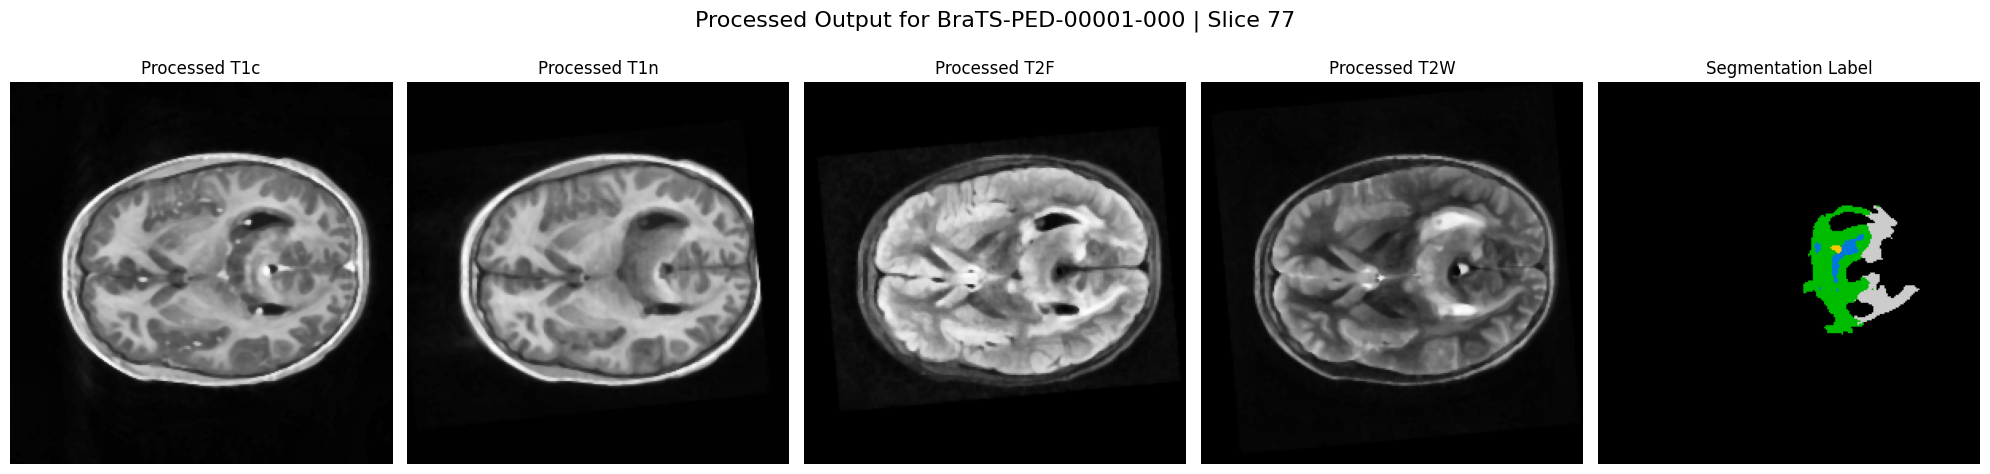

In [ ]:
import os
import torch
import matplotlib.pyplot as plt

# =====================================================================================
# Configuration
# =====================================================================================
# Directory where your processed .pt files are saved
save_dir = "/content/drive/MyDrive/BraTS Challenge 2025 - Task 6/BraTS2024-PED-Challenge-TrainingData/InputScans"

# The patient ID you want to visualize
patient_id_to_view = "BraTS-PED-00001-000"

# =====================================================================================
# Visualization Function
# =====================================================================================
def visualize_processed_pt(image_tensor, label_tensor, patient_id):
    """
    Visualizes the channels of a processed image tensor and its label.
    """
    # Convert tensors to numpy for plotting
    image = image_tensor.numpy()
    label = label_tensor.numpy()

    # Select the middle slice of the volume for display
    mid_slice_idx = image.shape[1] // 2

    # Create a figure with 5 subplots (4 modalities + 1 label)
    fig, axs = plt.subplots(1, 5, figsize=(20, 5))
    plt.suptitle(f"Processed Output for {patient_id} | Slice {mid_slice_idx}", fontsize=16)

    modality_titles = ["Processed T1c", "Processed T1n", "Processed T2F", "Processed T2W"]

    # Plot the 4 processed modality channels
    for i in range(4):
        axs[i].imshow(image[i, mid_slice_idx, :, :], cmap='gray')
        axs[i].set_title(modality_titles[i])
        axs[i].axis('off')

    # Plot the segmentation label
    axs[4].imshow(label[mid_slice_idx, :, :], cmap='nipy_spectral')
    axs[4].set_title("Segmentation Label")
    axs[4].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# =====================================================================================
# Main Execution Block
# =====================================================================================
if __name__ == "__main__":
    # Construct the full path to the processed file
    file_path = os.path.join(save_dir, f"{patient_id_to_view}.pt")

    if os.path.exists(file_path):
        print(f"Loading processed file: {file_path}")

        # Load the data dictionary from the .pt file
        data_dict = torch.load(file_path, map_location=torch.device('cpu'))

        # Extract the image and label tensors
        image_tensor = data_dict["image"].float() # Convert from half to float for visualization
        label_tensor = data_dict["label"]

        print(f"Image tensor shape: {image_tensor.shape}")
        print(f"Label tensor shape: {label_tensor.shape}")

        # Call the visualization function
        visualize_processed_pt(image_tensor, label_tensor, patient_id_to_view)

    else:
        print(f"ERROR: Processed file not found at {file_path}")

Patient 1: BraTS-PED-00215-000.pt


/tmp/ipython-input-13-3598989738.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(filepath, map_location="cpu")


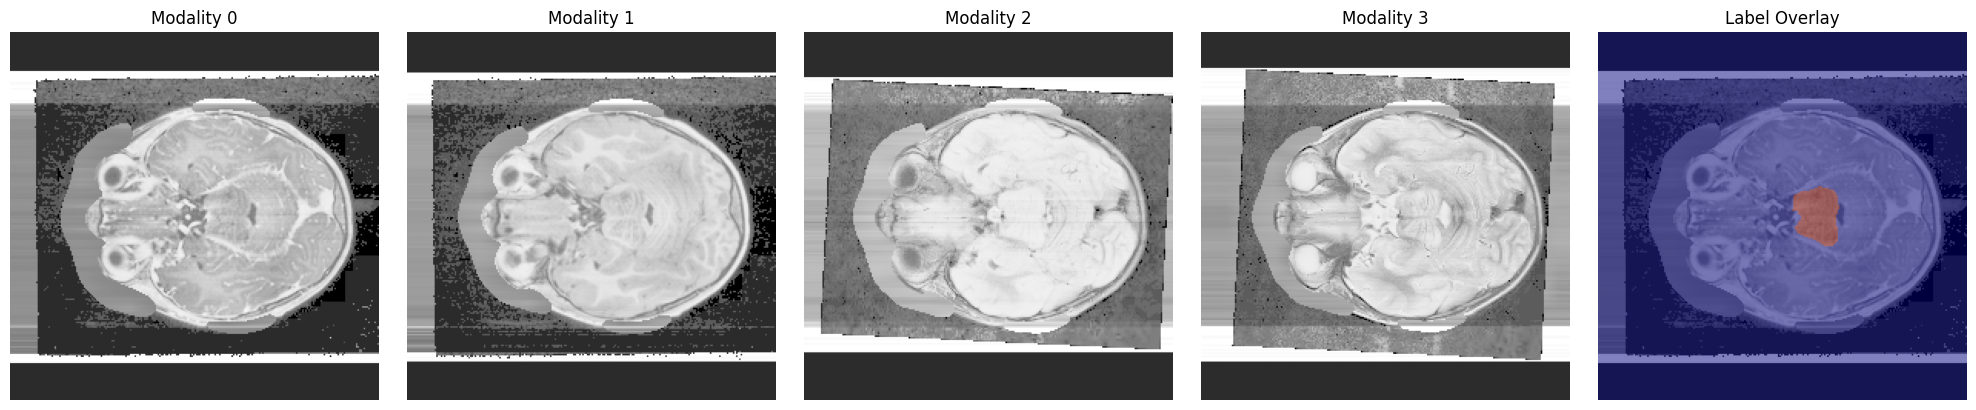

Patient 2: BraTS-PED-00237-000.pt


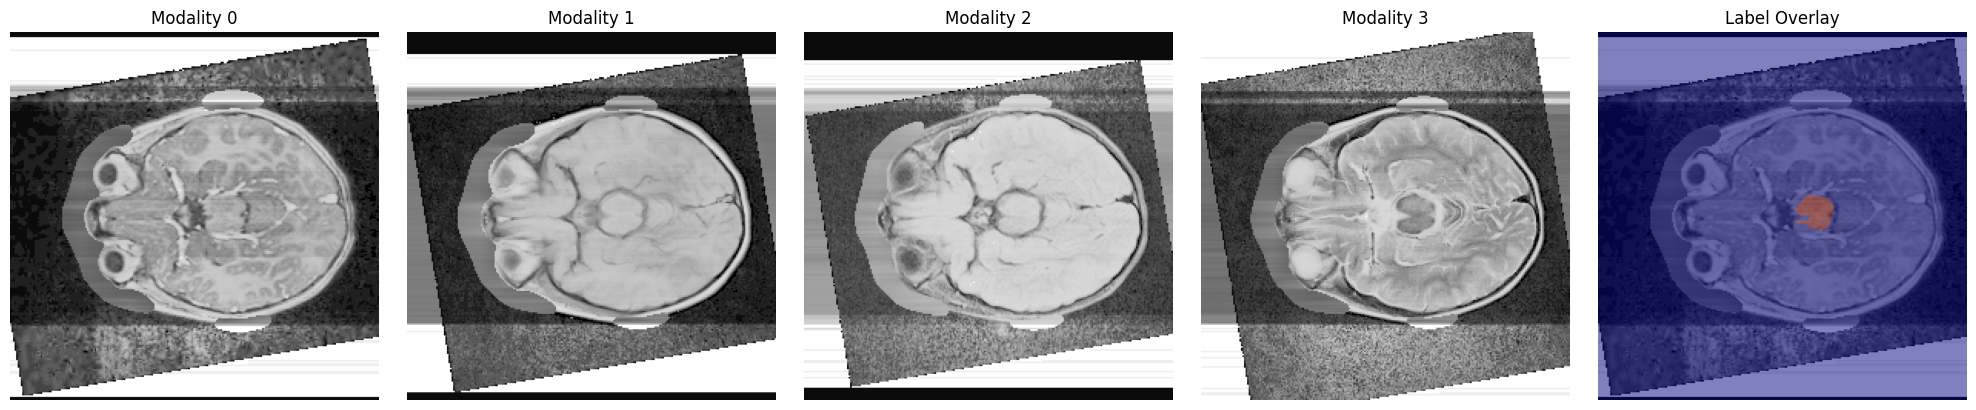

Patient 3: BraTS-PED-00119-000.pt


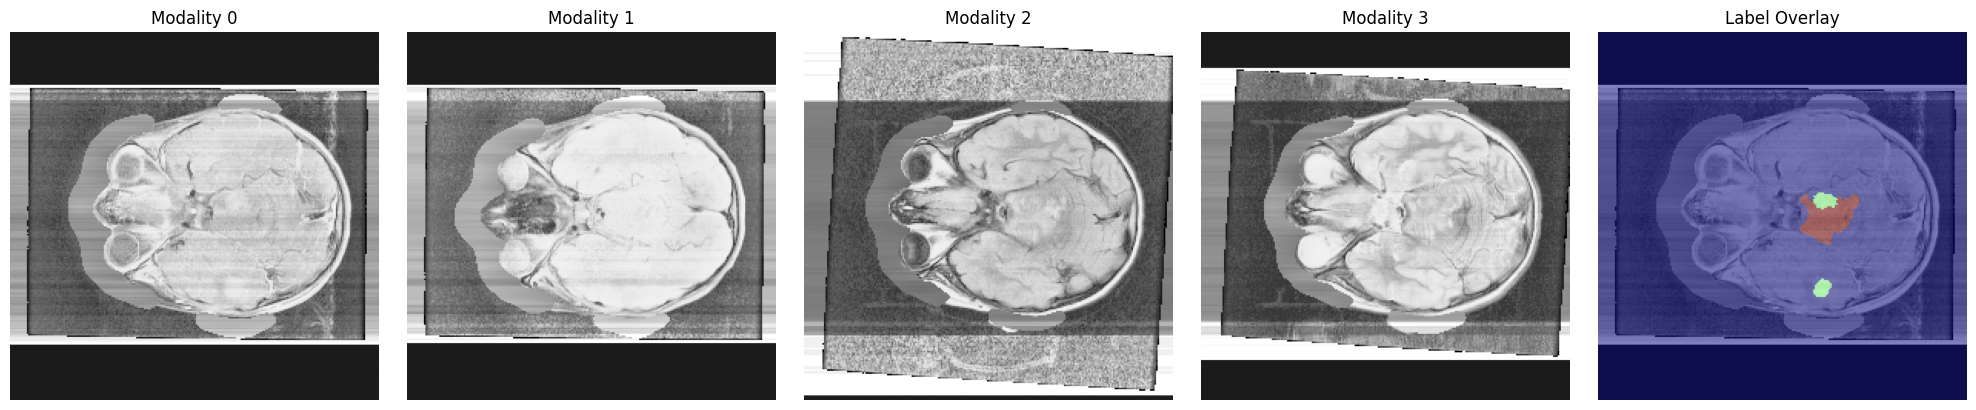

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
import random

# Set your path
processed_dir = "/content/drive/MyDrive/InputScans"
num_patients_to_visualize = 3  # Adjust as needed
slice_index = 60  # Mid-slice, adjust as needed

# Load random patients
pt_files = [f for f in os.listdir(processed_dir) if f.endswith(".pt")]
random.shuffle(pt_files)

def plot_patient(filepath):
    data = torch.load(filepath, map_location="cpu")
    image = data["image"].float()
    label = data["label"].long()

    num_modalities = image.shape[0]
    fig, axs = plt.subplots(1, num_modalities + 1, figsize=(4 * (num_modalities + 1), 4))

    for i in range(num_modalities):
        axs[i].imshow(image[i, :, :, slice_index], cmap="gray")
        axs[i].set_title(f"Modality {i}")
        axs[i].axis("off")

    # Overlay label
    axs[-1].imshow(image[0, :, :, slice_index], cmap="gray")
    axs[-1].imshow(label[:, :, slice_index], cmap="jet", alpha=0.5)
    axs[-1].set_title("Label Overlay")
    axs[-1].axis("off")

    plt.tight_layout()
    plt.show()

# Run visualization
for i in range(min(num_patients_to_visualize, len(pt_files))):
    print(f"Patient {i+1}: {pt_files[i]}")
    plot_patient(os.path.join(processed_dir, pt_files[i]))


Fixing of wrong scans

# Part-ii ; WITH VOXEL SPACING

In [ ]:
import os
import glob
import torch
import numpy as np
import SimpleITK as sitk
from tqdm import tqdm
import cv2
from joblib import Parallel, delayed
import traceback
# --- NEW: Import torchio for advanced medical image processing ---
import torchio as tio

# =====================================================================================
# Configuration
# =====================================================================================
data_root = "/content/drive/MyDrive/BraTS Challenge 2025 - Task 6/BraTS2024-PED-Challenge-TrainingData/BraTS-PEDs2024_Training"
modalities = ["t1c", "t1n", "t2f", "t2w"]
save_dir = "/content/drive/MyDrive/InputScans_Final"
os.makedirs(save_dir, exist_ok=True)

# --- NEW: Configuration for Resampling and Standardization ---
# TARGET_SPACING will be determined dynamically
TARGET_ORIENTATION = "RAI" # A standard anatomical orientation
NYUL_LANDMARKS_PATH = os.path.join(save_dir, "nyul_landmarks.npy")
NYUL_TRAINING_PATIENT_COUNT = 20 # Use first 20 patients to train the normalizer

# =====================================================================================
# Helper Functions (Updated and New)
# =====================================================================================

def get_median_spacing(patient_paths):
    """
    Analyzes the dataset to find the median voxel spacing.
    This is the best practice for determining the target resampling spacing.
    """
    spacings = []
    for patient_path in tqdm(patient_paths, desc="Analyzing Voxel Spacings"):
        patient_id = os.path.basename(patient_path)
        # We only need to check one modality per patient as they share the same space
        t1c_path = os.path.join(patient_path, f"{patient_id}-t1c.nii.gz")
        if os.path.exists(t1c_path):
            try:
                img_itk = sitk.ReadImage(t1c_path)
                spacings.append(img_itk.GetSpacing())
            except Exception as e:
                print(f"Could not read spacing for {patient_id}: {e}")

    if not spacings:
        raise RuntimeError("Could not read any spacings from the dataset. Check paths.")

    spacings_np = np.array(spacings)
    median_spacing = np.median(spacings_np, axis=0)
    return tuple(median_spacing)

def resample_and_reorient_sitk(sitk_image, target_spacing, target_orientation, is_label=False):
    """Resamples an image to a target spacing and reorients it."""
    original_spacing = sitk_image.GetSpacing()
    original_size = sitk_image.GetSize()

    # Calculate new size based on target spacing
    new_size = [
        int(round(osz * ospc / tspc))
        for osz, ospc, tspc in zip(original_size, original_spacing, target_spacing)
    ]

    # Set up the resampler
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(target_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(sitk_image.GetDirection())
    resampler.SetOutputOrigin(sitk_image.GetOrigin())
    resampler.SetTransform(sitk.Transform())
    resampler.SetDefaultPixelValue(sitk_image.GetPixelIDValue())

    if is_label:
        resampler.SetInterpolator(sitk.sitkNearestNeighbor)
    else:
        resampler.SetInterpolator(sitk.sitkBSpline)

    resampled_image = resampler.Execute(sitk_image)

    # Reorient the image
    orient_filter = sitk.DICOMOrientImageFilter()
    orient_filter.SetDesiredCoordinateOrientation(target_orientation)
    oriented_image = orient_filter.Execute(resampled_image)
    return oriented_image


def n4_bias_correction_fast(img_np):
    sitk_image = sitk.GetImageFromArray(img_np)
    sitk_image = sitk.Cast(sitk_image, sitk.sitkFloat32)
    mask_image = sitk.OtsuThreshold(sitk_image, 0, 1, 1)
    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrected_image = corrector.Execute(sitk_image, mask_image)
    return sitk.GetArrayFromImage(corrected_image)

def apply_anisotropic_diffusion(image_tensor):
    sitk_image = sitk.GetImageFromArray(image_tensor.numpy())
    diff_filter = sitk.CurvatureAnisotropicDiffusionImageFilter()
    diff_filter.SetTimeStep(0.0625)
    diff_filter.SetNumberOfIterations(5)
    diff_filter.SetConductanceParameter(9.0)
    filtered_image = diff_filter.Execute(sitk_image)
    return torch.from_numpy(sitk.GetArrayFromImage(filtered_image))

def get_gradient_magnitude(image_tensor):
    sitk_image = sitk.GetImageFromArray(image_tensor.float().numpy())
    grad_filter = sitk.GradientMagnitudeRecursiveGaussianImageFilter()
    grad_filter.SetSigma(1.0)
    grad_image = grad_filter.Execute(sitk_image)
    return torch.from_numpy(sitk.GetArrayFromImage(grad_image))

def enhance_contrast_cpu(image_tensor):
    img_np = image_tensor.detach().cpu().numpy()
    D, H, W = img_np.shape
    enhanced = np.zeros_like(img_np)
    for d in range(D):
        slice_ = img_np[d, :, :].astype(np.float32)
        if slice_.max() > slice_.min(): # Avoid errors on blank slices
            normalized = cv2.normalize(slice_, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            enhanced[d] = clahe.apply(normalized)
    return torch.tensor(enhanced).float()

def crop_to_brain_bounding_box(image, label, margin=5):
    """Crops to the bounding box of all non-black regions."""
    nonzero_mask = image.any(0)
    coords = torch.nonzero(nonzero_mask)
    if coords.numel() == 0: return None, None
    img_shape = image.shape[1:]
    minc = torch.clamp(coords.min(dim=0)[0] - margin, min=0)
    maxc = torch.clamp(coords.max(dim=0)[0] + margin, max=torch.tensor(img_shape))
    d_min, h_min, w_min = minc.tolist()
    d_max, h_max, w_max = maxc.tolist()
    cropped_image = image[:, d_min:d_max, h_min:h_max, w_min:w_max]
    cropped_label = label[d_min:d_max, h_min:h_max, w_min:w_max]
    return cropped_image, cropped_label

# =====================================================================================
# Main Patient Processing Function (Updated)
# =====================================================================================
def process_patient(patient_path, nyul_normalizer, target_spacing):
    patient_id = os.path.basename(patient_path)
    output_file = os.path.join(save_dir, f"{patient_id}.pt")
    temp_output_file = output_file + ".tmp"

    if os.path.exists(output_file): return "skipped", patient_id
    if os.path.exists(temp_output_file): os.remove(temp_output_file)

    try:
        # --- 1. Load and Resample/Reorient each modality and label ---
        resampled_modalities = []
        for m in modalities:
            filepath = os.path.join(patient_path, f"{patient_id}-{m}.nii.gz")
            img_itk = sitk.ReadImage(filepath, sitk.sitkFloat32)
            resampled_img_itk = resample_and_reorient_sitk(img_itk, target_spacing, TARGET_ORIENTATION, is_label=False)
            resampled_modalities.append(torch.from_numpy(sitk.GetArrayFromImage(resampled_img_itk)))

        label_filepath = os.path.join(patient_path, f"{patient_id}-seg.nii.gz")
        label_itk = sitk.ReadImage(label_filepath, sitk.sitkInt64)
        resampled_label_itk = resample_and_reorient_sitk(label_itk, target_spacing, TARGET_ORIENTATION, is_label=True)
        label_tensor = torch.from_numpy(sitk.GetArrayFromImage(resampled_label_itk)).long()

        modalities_tensor = torch.stack(resampled_modalities)

        # --- 2. N4 Bias Field Correction ---
        image_n4 = torch.stack([torch.tensor(n4_bias_correction_fast(modalities_tensor[i].numpy())) for i in range(4)])

        # --- 3. Nyul Histogram Standardization (replaces z-score) ---
        image_nyul = torch.stack([nyul_normalizer(img.unsqueeze(0), mask=img > img.min())[0] for img in image_n4])

        # --- 4. Denoising, Enhancement, and Gradient Map ---
        image_aniso = torch.stack([apply_anisotropic_diffusion(image_nyul[i]) for i in range(4)])
        image_enhanced = torch.stack([enhance_contrast_cpu(img) for img in image_aniso])
        grad_map = get_gradient_magnitude(image_enhanced[0]).unsqueeze(0)

        final_image_to_crop = torch.cat([image_enhanced, grad_map], dim=0)

        # --- 5. Crop to Brain Bounding Box ---
        cropped_image, cropped_label = crop_to_brain_bounding_box(final_image_to_crop, label_tensor)

        if cropped_image is None: return "error_empty_image", patient_id

        # --- 6. ATOMIC SAVE: Save to a temporary file first. ---
        # This ensures that if the script crashes during saving, we are left with
        # a .tmp file, not a corrupted .pt file. The script will clean up
        # .tmp files on the next run.
        torch.save({"image": cropped_image.half(), "label": cropped_label}, temp_output_file)

        # The os.rename operation is atomic on most filesystems. This means it
        # either completes successfully or not at all, preventing corruption.
        os.rename(temp_output_file, output_file)

        return "processed", patient_id

    except Exception as e:
        if os.path.exists(temp_output_file): os.remove(temp_output_file)
        return "error", patient_id, str(e)

# =====================================================================================
# Execution Block for the ENTIRE DATASET (Updated)
# =====================================================================================
def safe_process(patient_path, nyul_normalizer, target_spacing):
    """Wrapper to catch unexpected crashes in the parallel execution."""
    try:
        return process_patient(patient_path, nyul_normalizer, target_spacing)
    except Exception as e:
        return "crash", os.path.basename(patient_path), str(e)

if __name__ == "__main__":
    all_patients = sorted(glob.glob(os.path.join(data_root, "BraTS-PED-*")))
    print(f"Found {len(all_patients)} patients to process.")

    # --- NEW: Dynamically determine the best target spacing ---
    TARGET_SPACING = get_median_spacing(all_patients)
    print(f"Using dynamically calculated median spacing: {TARGET_SPACING}")

    # --- Train Nyul Normalizer if it doesn't exist ---
    if not os.path.exists(NYUL_LANDMARKS_PATH):
        print(f"Nyul landmarks not found. Training on first {NYUL_TRAINING_PATIENT_COUNT} patients...")
        training_paths = all_patients[:NYUL_TRAINING_PATIENT_COUNT]

        subjects = []
        for patient_path in tqdm(training_paths, desc="Loading Nyul Training Data"):
            patient_id = os.path.basename(patient_path)
            t1c_path = os.path.join(patient_path, f"{patient_id}-t1c.nii.gz")
            if os.path.exists(t1c_path):
                subjects.append(tio.Subject(image=tio.ScalarImage(t1c_path)))

        nyul_transform = tio.NyulStandardization(masking_method=tio.MaskingMethod.OTSU)
        nyul_transform.train(subjects)

        torch.save(nyul_transform.landmarks, NYUL_LANDMARKS_PATH)
        print(f"Nyul landmarks trained and saved to {NYUL_LANDMARKS_PATH}")

    # --- Load the trained normalizer for processing all patients ---
    print("Loading pre-trained Nyul landmarks...")
    landmarks = torch.load(NYUL_LANDMARKS_PATH)
    nyul_normalizer = tio.NyulStandardization(landmarks=landmarks)

    # Delete old log files
    for log_type in ["processed", "skipped", "errored", "crashed"]:
        log_file = os.path.join(save_dir, f"{log_type}_patients.txt")
        if os.path.exists(log_file):
            os.remove(log_file)

    # Use joblib to run the preprocessing in parallel
    results = Parallel(n_jobs=-1)(
        delayed(safe_process)(p, nyul_normalizer, TARGET_SPACING) for p in tqdm(all_patients, desc="Preprocessing Patients")
    )

    # --- Log the results ---
    processed = {r[1] for r in results if r[0] == "processed"}
    skipped = {r[1] for r in results if "skipped" in r[0]}
    errored = {r[1]: r[2] for r in results if r[0] == "error"}
    crashed = {r[1]: r[2] for r in results if r[0] == "crash"}

    with open(os.path.join(save_dir, "processed_patients.txt"), "w") as f:
        for p in sorted(processed): f.write(f"{p}\n")
    with open(os.path.join(save_dir, "skipped_patients.txt"), "w") as f:
        for p in sorted(skipped): f.write(f"{p}\n")
    with open(os.path.join(save_dir, "errored_patients.txt"), "w") as f:
        for p, err in errored.items(): f.write(f"{p}: {err}\n")
    with open(os.path.join(save_dir, "crashed_patients.txt"), "w") as f:
        for p, err in crashed.items(): f.write(f"{p}: {err}\n")

    print(f"\n--- Preprocessing Complete ---")
    print(f"Successfully processed: {len(processed)}")
    print(f"Skipped: {len(skipped)}")
    print(f"Errored: {len(errored)}")
    print(f"Crashed: {len(crashed)}")


Found 261 patients to process.


Analyzing Voxel Spacings: 100%|██████████| 261/261 [09:25<00:00,  2.17s/it]


Using dynamically calculated median spacing: (np.float64(1.0), np.float64(1.0), np.float64(1.0))
Nyul landmarks not found. Training on first 20 patients...


Loading Nyul Training Data: 100%|██████████| 20/20 [00:00<00:00, 652.52it/s]


AttributeError: module 'torchio' has no attribute 'NyulStandardization'

In [ ]:
import torchio as tio
print(f"Installed TorchIO version: {tio.__version__}")

Installed TorchIO version: 0.20.19


Reverting to the previous preprocessing code without TorchIO.

In [ ]:
import os
import glob
import torch
import numpy as np
import SimpleITK as sitk
from tqdm import tqdm
import cv2
from joblib import Parallel, delayed
import traceback

# =====================================================================================
# Configuration
# =====================================================================================
data_root = "/content/drive/MyDrive/BraTS Challenge 2025 - Task 6/BraTS2024-PED-Challenge-TrainingData/BraTS-PEDs2024_Training"
modalities = ["t1c", "t1n", "t2f", "t2w"]
save_dir = "/content/drive/MyDrive/InputScans_Final" # Using the final save directory
os.makedirs(save_dir, exist_ok=True)

# =====================================================================================
# All 5 Helper Functions
# =====================================================================================
def n4_bias_correction_fast(img_np):
    sitk_image = sitk.GetImageFromArray(img_np)
    sitk_image = sitk.Cast(sitk_image, sitk.sitkFloat32)
    shrink_factor = [4, 4, 4]
    shrunk_image = sitk.Shrink(sitk_image, shrink_factor)
    mask = sitk.OtsuThreshold(shrunk_image, 0, 1)
    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrector.Execute(shrunk_image, mask)
    log_bias_field = corrector.GetLogBiasFieldAsImage(shrunk_image)
    restored_log_bias_field = sitk.Resample(log_bias_field, sitk_image)
    corrected_image_full_resolution = sitk.Divide(sitk_image, sitk.Exp(restored_log_bias_field))
    return sitk.GetArrayFromImage(corrected_image_full_resolution)

def apply_anisotropic_diffusion(image_tensor):
    sitk_image = sitk.GetImageFromArray(image_tensor.numpy())
    diff_filter = sitk.CurvatureAnisotropicDiffusionImageFilter()
    diff_filter.SetTimeStep(0.0625)
    diff_filter.SetNumberOfIterations(5)
    diff_filter.SetConductanceParameter(9.0)
    filtered_image = diff_filter.Execute(sitk_image)
    return torch.from_numpy(sitk.GetArrayFromImage(filtered_image))

def get_gradient_magnitude(image_tensor):
    sitk_image = sitk.GetImageFromArray(image_tensor.float().numpy())
    grad_filter = sitk.GradientMagnitudeRecursiveGaussianImageFilter()
    grad_filter.SetSigma(1.0)
    grad_image = grad_filter.Execute(sitk_image)
    return torch.from_numpy(sitk.GetArrayFromImage(grad_image))

def enhance_contrast_cpu(image_tensor):
    img_np = image_tensor.detach().cpu().numpy()
    # The original code had C, D, H, W shape, assuming [C, D, H, W].
    # After loading and permuting to [D, H, W], the shape should be D, H, W for a single channel.
    # This function expects a single 3D tensor [D, H, W].
    D, H, W = img_np.shape
    enhanced = np.zeros_like(img_np)
    for d in range(D):
        slice_ = img_np[d, :, :].astype(np.float32)
        if slice_.max() > slice_.min(): # Avoid errors on blank slices
            normalized = cv2.normalize(slice_, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            enhanced[d] = clahe.apply(normalized)
    return torch.tensor(enhanced).float()


def crop_to_brain_bounding_box(image, label, margin=5):
    """Crops to the bounding box of all non-black regions."""
    # The input image is expected to be [C, D, H, W]
    nonzero_mask = image.any(0) # Find non-zero voxels across channels
    coords = torch.nonzero(nonzero_mask)
    if coords.numel() == 0: return None, None
    img_shape = image.shape[1:] # Get D, H, W dimensions
    minc = torch.clamp(coords.min(dim=0)[0] - margin, min=0)
    maxc = torch.clamp(coords.max(dim=0)[0] + margin, max=torch.tensor(img_shape))
    d_min, h_min, w_min = minc.tolist()
    d_max, h_max, w_max = maxc.tolist()
    cropped_image = image[:, d_min:d_max, h_min:h_max, w_min:w_max]
    cropped_label = label[d_min:d_max, h_min:h_max, w_min:w_max]
    return cropped_image, cropped_label

# =====================================================================================
# Main Patient Processing Function
# =====================================================================================
def process_patient(patient_path):
    patient_id = os.path.basename(patient_path)
    output_file = os.path.join(save_dir, f"{patient_id}.pt")
    temp_output_file = output_file + ".tmp"

    # Skip if already processed or temp file exists (cleanup temp)
    if os.path.exists(output_file): return "skipped", patient_id
    if os.path.exists(temp_output_file): os.remove(temp_output_file)


    try:
        from monai.transforms import LoadImage
        image_loader = LoadImage(image_only=True)

        # 1. Load Data and Standardize Dimensions to [D, H, W] per modality
        modalities_list = []
        for m in modalities:
            filepath = os.path.join(patient_path, f"{patient_id}-{m}.nii.gz")
            if not os.path.exists(filepath):
                 print(f"Missing file: {filepath}. Skipping patient {patient_id}.")
                 return "skipped_missing_file", patient_id
            # MONAI loads as [H, W, D], permute to [D, H, W]
            modalities_list.append(torch.from_numpy(image_loader(filepath).numpy()).float().permute(2, 0, 1))

        # Stack modalities to get [C, D, H, W]
        modalities_tensor = torch.stack(modalities_list)

        # Load and permute label to [D, H, W]
        label_filepath = os.path.join(patient_path, f"{patient_id}-seg.nii.gz")
        if not os.path.exists(label_filepath):
             print(f"Missing label file: {label_filepath}. Skipping patient {patient_id}.")
             return "skipped_missing_label", patient_id
        label_tensor = torch.from_numpy(image_loader(label_filepath).numpy()).long().permute(2, 0, 1)


        # 2. N4 Bias Field Correction - Apply to each modality [D, H, W] independently
        image_n4 = torch.stack([torch.tensor(n4_bias_correction_fast(modalities_tensor[i].numpy())) for i in range(4)])

        # 3. Simple Z-score Normalization (Replacing Nyul)
        # Calculate mean and std based on brain mask across all 4 corrected modalities
        # Create a temporary brain mask from corrected images
        temp_brain_mask = (image_n4 > image_n4.min()).any(0) # Mask non-min value voxels (approximate brain)
        # Expand mask to 4 channels for broadcasting
        mask_4ch = temp_brain_mask.unsqueeze(0).expand(4, -1, -1, -1)
        # Calculate mean and std only within the masked region
        mean = image_n4[mask_4ch].mean()
        std = image_n4[mask_4ch].std()
        image_normalized = (image_n4 - mean) / (std + 1e-8) # Add epsilon for stability

        # 4. Denoising (Anisotropic Diffusion) - Apply to each normalized modality [D, H, W] independently
        image_aniso = torch.stack([apply_anisotropic_diffusion(image_normalized[i]) for i in range(4)])

        # 5. Contrast Enhancement (CLAHE) - Apply to each denoised modality [D, H, W] independently
        # enhance_contrast_cpu expects a single 3D tensor, so iterate
        image_enhanced_list = [enhance_contrast_cpu(image_aniso[i]) for i in range(4)]
        image_enhanced = torch.stack(image_enhanced_list)

        # 6. Gradient Magnitude Feature - Apply to the first enhanced modality (e.g., T1c)
        grad_map = get_gradient_magnitude(image_enhanced[0]).unsqueeze(0) # Adds channel dimension back

        # 7. Combine channels: [T1c, T1n, T2F, T2W, Gradient] -> [5, D, H, W]
        final_image_to_crop = torch.cat([image_enhanced, grad_map], dim=0)

        # 8. Crop to Brain Bounding Box
        # crop_to_brain_bounding_box expects [C, D, H, W] for image and [D, H, W] for label
        cropped_image, cropped_label = crop_to_brain_bounding_box(final_image_to_crop, label_tensor)

        if cropped_image is None:
            print(f"Cropped image is empty for patient {patient_id}. Skipping.")
            return "error_empty_image", patient_id

        # 9. Atomic Save
        # Save image as half precision to save space
        torch.save({"image": cropped_image.half(), "label": cropped_label}, temp_output_file)
        os.rename(temp_output_file, output_file)

        return "processed", patient_id

    except FileNotFoundError as e:
        # This case should be handled by the check at the beginning, but keeping for robustness
        print(f"FileNotFoundError processing {patient_id}: {e}")
        if os.path.exists(temp_output_file): os.remove(temp_output_file)
        return "error_file_not_found", patient_id, str(e)
    except Exception as e:
        print(f"Error processing patient {patient_id}: {e}")
        traceback.print_exc() # Print traceback for debugging
        if os.path.exists(temp_output_file): os.remove(temp_output_file)
        return "error", patient_id, str(e)

# =====================================================================================
# Parallel Wrapper and Execution Block
# =====================================================================================

def safe_process(patient_path):
    """Wrapper to catch unexpected crashes in the parallel execution."""
    try:
        return process_patient(patient_path)
    except Exception as e:
        print(f"Crash during processing patient {os.path.basename(patient_path)}: {e}")
        traceback.print_exc() # Print traceback for debugging
        return "crash", os.path.basename(patient_path), str(e)


if __name__ == "__main__":
    all_patients = sorted(glob.glob(os.path.join(data_root, "BraTS-PED-*")))
    print(f"Found {len(all_patients)} patients to process.")

    # Delete old log files before starting a new run
    for log_type in ["processed", "skipped", "errored", "crashed", "skipped_missing_file", "skipped_missing_label", "error_empty_image", "error_file_not_found"]:
        log_file = os.path.join(save_dir, f"{log_type}_patients.txt")
        if os.path.exists(log_file):
            os.remove(log_file)

    # Use joblib to run the preprocessing in parallel on all available CPU cores
    results = Parallel(n_jobs=-1)(
        delayed(safe_process)(p) for p in tqdm(all_patients, desc="Preprocessing Patients")
    )

    # --- Log the results of the run ---
    processed = {r[1] for r in results if r[0] == "processed"}
    skipped = {r[1] for r in results if "skipped" in r[0]} # Includes all skipped types
    errored = {r[1]: r[2] for r in results if r[0] == "error"}
    crashed = {r[1]: r[2] for r in results if r[0] == "crash"}
    skipped_missing_file = {r[1] for r in results if r[0] == "skipped_missing_file"}
    skipped_missing_label = {r[1] for r in results if r[0] == "skipped_missing_label"}
    error_empty_image = {r[1] for r in results if r[0] == "error_empty_image"}
    error_file_not_found = {r[1]: r[2] for r in results if r[0] == "error_file_not_found"}


    with open(os.path.join(save_dir, "processed_patients.txt"), "w") as f:
        for p in sorted(processed): f.write(f"{p}\n")
    with open(os.path.join(save_dir, "skipped_patients.txt"), "w") as f:
        for p in sorted(skipped): f.write(f"{p}\n")
    with open(os.path.join(save_dir, "errored_patients.txt"), "w") as f:
        for p, err in errored.items(): f.write(f"{p}: {err}\n")
    with open(os.path.join(save_dir, "crashed_patients.txt"), "w") as f:
        for p, err in crashed.items(): f.write(f"{p}: {err}\n")
    with open(os.path.join(save_dir, "skipped_missing_file_patients.txt"), "w") as f:
        for p in sorted(skipped_missing_file): f.write(f"{p}\n")
    with open(os.path.join(save_dir, "skipped_missing_label_patients.txt"), "w") as f:
        for p in sorted(skipped_missing_label): f.write(f"{p}\n")
    with open(os.path.join(save_dir, "error_empty_image_patients.txt"), "w") as f:
        for p in sorted(error_empty_image): f.write(f"{p}\n")
    with open(os.path.join(save_dir, "error_file_not_found_patients.txt"), "w") as f:
        for p, err in error_file_not_found.items(): f.write(f"{p}: {err}\n")


    print(f"\n--- Preprocessing Complete ---")
    print(f"Successfully processed: {len(processed)}")
    print(f"Total Skipped: {len(skipped)}") # Total of all skipped types
    print(f"  Skipped (Missing File): {len(skipped_missing_file)}")
    print(f"  Skipped (Missing Label): {len(skipped_missing_label)}")
    print(f"  Skipped (Empty Image After Crop): {len(error_empty_image)}")
    print(f"Errored: {len(errored)}") # Generic errors with traceback
    print(f"Crashed: {len(crashed)}") # Unexpected crashes with traceback
    print(f"Error (File Not Found - Redundant Check): {len(error_file_not_found)}") # Should be covered by skipped_missing_file/label

Found 261 patients to process.


Preprocessing Patients:  11%|█▏        | 30/261 [57:01<7:49:07, 121.85s/it]